**Purpose**  
Assess whether urban form indicators can be summarized by a smaller set
of latent dimensions, and whether results are robust to:
- aggregation choice (MEAN vs MEDIAN)
- method choice (PCA vs SOM).

**Design**
- A. MEAN scores → PCA (k by scree), PCA (all components), SOM (3×3)
- B. MEDIAN scores → same sequence

In [22]:
# ============================================================
# 0. Setup
# ============================================================

import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from factor_analyzer.rotator import Rotator
from minisom import MiniSom

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

pd.set_option("display.float_format", "{:.6f}".format)

In [23]:
# ============================================================
# 0.1 Load Data
# ============================================================

ABT = gpd.read_file(
    "../../../../Data/Final_dataset/ABT/ABT.gpkg",
    layer="subdivisions"
)

ABT = ABT[(ABT["year"] >= 1990) & (ABT["year"] <= 2023)].copy()

In [24]:
# ============================================================
# 0.2 Indicator Set
# ============================================================

measures = [
    'COMPACTNESS_SUM',
    'BAD_ctx_025', 'BAD_ctx_050',
    "HAC_dist",
    "BAD",
    'FAR',
    "SHD",
    "int_den025",
    "nd_deg025",
    "int_den05",
    "nd_deg05",
    "int_den075",
    "nd_deg075",
    "int_den1",
    "nd_deg1",
    'groceries_ws', 'transit_ws'
]

missing = [m for m in measures if m not in ABT.columns]
if missing:
    raise ValueError(f"Missing measures: {missing}")

In [26]:
# ============================================================
# 0.3 Subdivision ID and Core Table
# ============================================================

subdiv_id_col = "subd_id"
ABT_core = ABT[[subdiv_id_col, "year"] + measures].copy()

## 1. Cross-Section Construction

Annual subdivision indicators (1990–2023) are collapsed using
MEAN and MEDIAN aggregation, then standardized separately.


In [27]:
def build_cross_section(df, id_col, measures, agg="mean"):
    g = df.groupby(id_col)[measures]
    if agg == "mean":
        X = g.mean()
    elif agg == "median":
        X = g.median()
    else:
        raise ValueError("agg must be 'mean' or 'median'")
    return X.dropna()

X_mean = build_cross_section(ABT_core, subdiv_id_col, measures, "mean")
X_median = build_cross_section(ABT_core, subdiv_id_col, measures, "median")

print("X_mean shape:", X_mean.shape)
print("X_median shape:", X_median.shape)

X_mean shape: (5844, 17)
X_median shape: (5844, 17)


In [28]:
def zscore_df(X):
    scaler = StandardScaler()
    return pd.DataFrame(
        scaler.fit_transform(X.values),
        index=X.index,
        columns=X.columns
    )

Xz_mean = zscore_df(X_mean)
Xz_median = zscore_df(X_median)

In [29]:
def fit_pca_full(Xz):
    pca = PCA()
    scores = pca.fit_transform(Xz.values)
    explained = pd.DataFrame({
        "Eigenvalue": pca.explained_variance_,
        "Variance Share": pca.explained_variance_ratio_,
        "Cumulative Share": np.cumsum(pca.explained_variance_ratio_)
    }, index=[f"PC{i + 1}" for i in range(Xz.shape[1])])

    loadings = pd.DataFrame(
        pca.components_.T,
        index=Xz.columns,
        columns=explained.index
    )
    return scores, explained, loadings


def plot_scree(explained, title):
    ev = explained["Eigenvalue"].values
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(ev) + 1), ev, marker="o")
    plt.axhline(1, color="gray", linestyle="--", label="Kaiser λ=1")
    plt.xlabel("Component")
    plt.ylabel("Eigenvalue")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def choose_k_kaiser(explained):
    return int((explained["Eigenvalue"] > 1).sum())


def varimax_rotate(loadings):
    rot = Rotator(method="varimax", normalize=True)
    return pd.DataFrame(
        rot.fit_transform(loadings.values),
        index=loadings.index,
        columns=loadings.columns
    )


def summarize_top_loadings(loadings, top_n=6, threshold=0.35):
    rows = []
    for c in loadings.columns:
        s = loadings[c].abs().sort_values(ascending=False)
        for v in s.head(top_n).index:
            val = loadings.loc[v, c]
            if abs(val) >= threshold:
                rows.append((c, v, val))
    return pd.DataFrame(rows, columns=["Component", "Variable", "Loading"])

## 3. A. MEAN Scores

,Eigenvalue,Variance Share,Cumulative Share
PC1,9.151900,0.538255,0.538255
PC2,1.455450,0.085600,0.623855
PC3,1.125295,0.066183,0.690037
PC4,0.940742,0.055328,0.745366
PC5,0.792179,0.046591,0.791957
PC6,0.727649,0.042796,0.834752
PC7,0.639675,0.037622,0.872374
PC8,0.515117,0.030296,0.902669
PC9,0.498978,0.029347,0.932016
PC10,0.352775,0.020748,0.952764


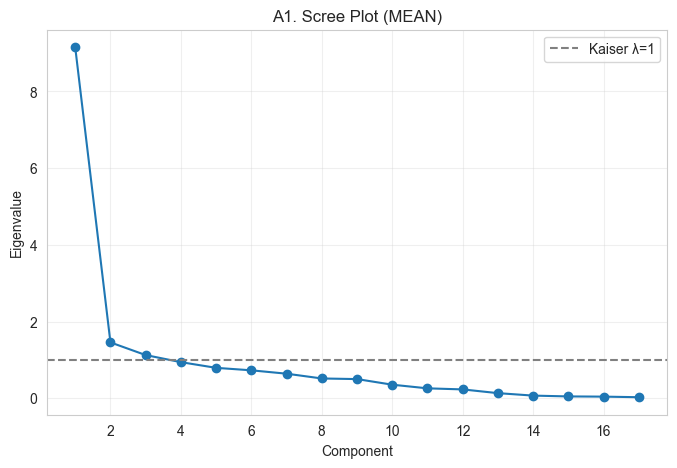

Chosen k (MEAN): 3


,PC1,PC2,PC3
COMPACTNESS_SUM,-0.128607,0.346143,-0.044925
BAD_ctx_025,0.098853,0.359835,0.013297
BAD_ctx_050,0.122928,0.351938,0.016549
HAC_dist,-0.148844,-0.127284,-0.075333
BAD,-0.044105,0.446885,0.008708
FAR,-0.242678,0.488153,0.058567
SHD,-0.515573,-0.024804,0.554315
int_den025,0.348403,-0.067590,0.163543
nd_deg025,0.103950,-0.088306,0.416371
int_den05,0.383577,-0.014906,0.122009


,Component,Variable,Loading
0,PC1,SHD,-0.515573
1,PC1,int_den075,0.386165
2,PC1,int_den05,0.383577
3,PC1,int_den1,0.367431
4,PC2,FAR,0.488153
5,PC2,BAD,0.446885
6,PC2,BAD_ctx_025,0.359835
7,PC2,BAD_ctx_050,0.351938
8,PC3,SHD,0.554315
9,PC3,nd_deg05,0.422513


In [30]:
# A1. PCA (MEAN): k by scree / Kaiser

scores_mean, explained_mean, loadings_mean = fit_pca_full(Xz_mean)

display(explained_mean.head(10))
plot_scree(explained_mean, "A1. Scree Plot (MEAN)")

k_mean = max(1, choose_k_kaiser(explained_mean))
print("Chosen k (MEAN):", k_mean)

rot_mean_k = varimax_rotate(loadings_mean.iloc[:, :k_mean])
display(rot_mean_k)
display(summarize_top_loadings(rot_mean_k))

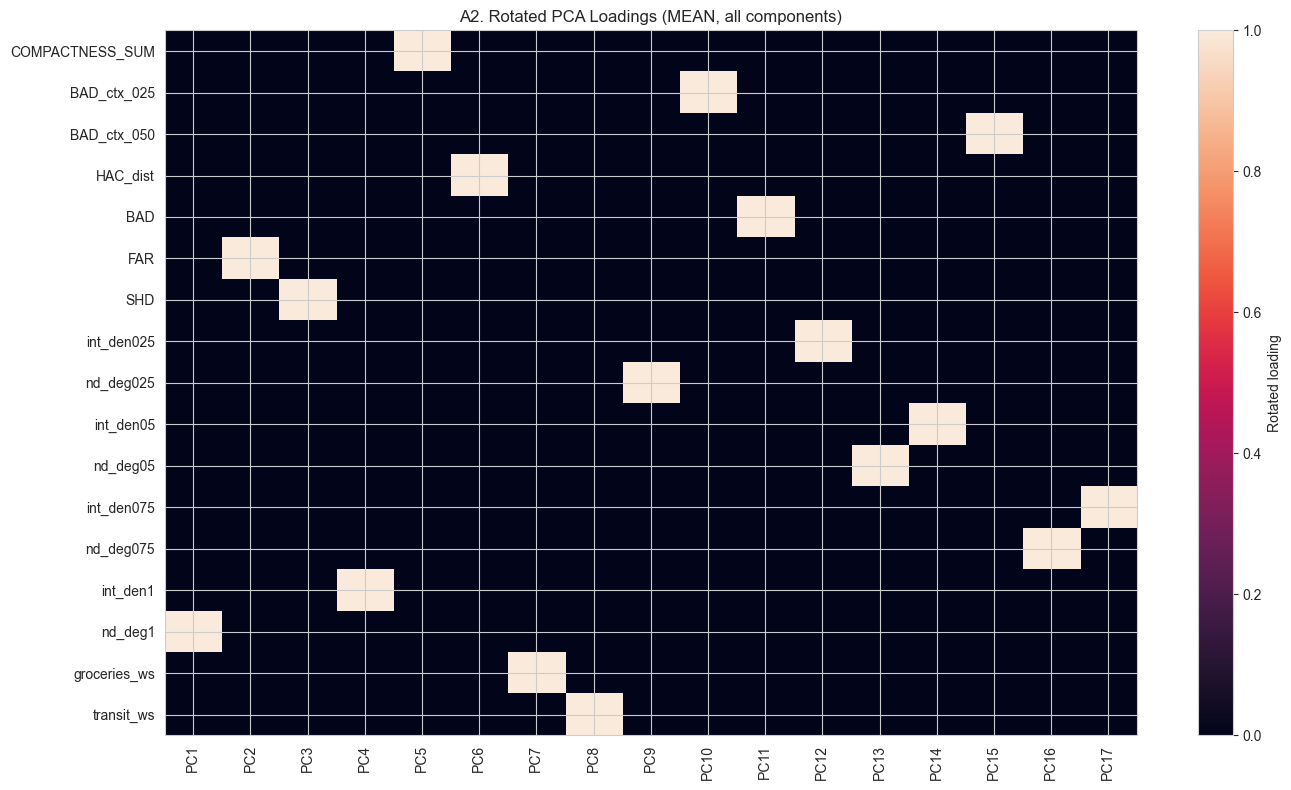

In [31]:
# A2. PCA (MEAN): all components, varimax

rot_mean_full = varimax_rotate(loadings_mean)

plt.figure(figsize=(14, 8))
plt.imshow(rot_mean_full.values, aspect="auto")
plt.colorbar(label="Rotated loading")
plt.yticks(range(len(rot_mean_full.index)), rot_mean_full.index)
plt.xticks(range(len(rot_mean_full.columns)), rot_mean_full.columns, rotation=90)
plt.title("A2. Rotated PCA Loadings (MEAN, all components)")
plt.tight_layout()
plt.show()


### A3. SOM (MEAN)


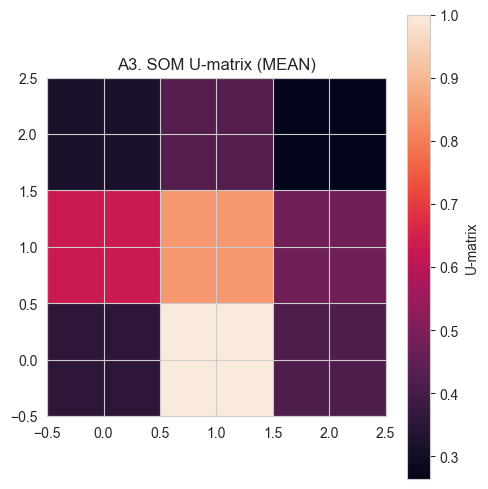

In [32]:
def train_som(Xz, grid=(3, 3), n_iter=5000):
    som = MiniSom(
        grid[0], grid[1],
        input_len=Xz.shape[1],
        sigma=1.0,
        learning_rate=0.5,
        random_seed=RANDOM_SEED
    )
    som.random_weights_init(Xz.values)
    som.train(Xz.values, n_iter)
    return som


def som_bmu_df(som, Xz):
    bmu = [som.winner(v) for v in Xz.values]
    return pd.DataFrame(bmu, index=Xz.index, columns=["som_x", "som_y"])


def plot_umatrix(som, title):
    plt.figure(figsize=(5, 5))
    plt.imshow(som.distance_map(), origin="lower")
    plt.colorbar(label="U-matrix")
    plt.title(title)
    plt.tight_layout()
    plt.show()


som_mean = train_som(Xz_mean)
bmu_mean = som_bmu_df(som_mean, Xz_mean)

plot_umatrix(som_mean, "A3. SOM U-matrix (MEAN)")

## 4. B. MEDIAN Scores


,Eigenvalue,Variance Share,Cumulative Share
PC1,9.151900,0.538255,0.538255
PC2,1.455450,0.085600,0.623855
PC3,1.125295,0.066183,0.690037
PC4,0.940742,0.055328,0.745366
PC5,0.792179,0.046591,0.791957
PC6,0.727649,0.042796,0.834752
PC7,0.639675,0.037622,0.872374
PC8,0.515117,0.030296,0.902669
PC9,0.498978,0.029347,0.932016
PC10,0.352775,0.020748,0.952764


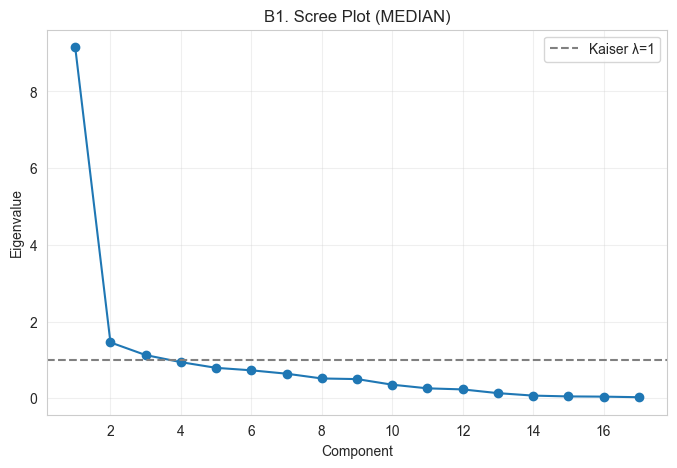

Chosen k (MEDIAN): 3


,PC1,PC2,PC3
COMPACTNESS_SUM,-0.128607,0.346143,-0.044925
BAD_ctx_025,0.098853,0.359835,0.013297
BAD_ctx_050,0.122928,0.351938,0.016549
HAC_dist,-0.148844,-0.127284,-0.075333
BAD,-0.044105,0.446885,0.008708
FAR,-0.242678,0.488153,0.058567
SHD,-0.515573,-0.024804,0.554315
int_den025,0.348403,-0.067590,0.163543
nd_deg025,0.103950,-0.088306,0.416371
int_den05,0.383577,-0.014906,0.122009


,Component,Variable,Loading
0,PC1,SHD,-0.515573
1,PC1,int_den075,0.386165
2,PC1,int_den05,0.383577
3,PC1,int_den1,0.367431
4,PC2,FAR,0.488153
5,PC2,BAD,0.446885
6,PC2,BAD_ctx_025,0.359835
7,PC2,BAD_ctx_050,0.351938
8,PC3,SHD,0.554315
9,PC3,nd_deg05,0.422513


In [38]:
# B1. PCA (MEDIAN): k by scree / Kaiser

scores_med, explained_med, loadings_med = fit_pca_full(Xz_median)

display(explained_med.head(10))
plot_scree(explained_med, "B1. Scree Plot (MEDIAN)")

k_med = max(1, choose_k_kaiser(explained_med))
print("Chosen k (MEDIAN):", k_med)

rot_med_k = varimax_rotate(loadings_med.iloc[:, :k_med])
display(rot_med_k)
display(summarize_top_loadings(rot_med_k))

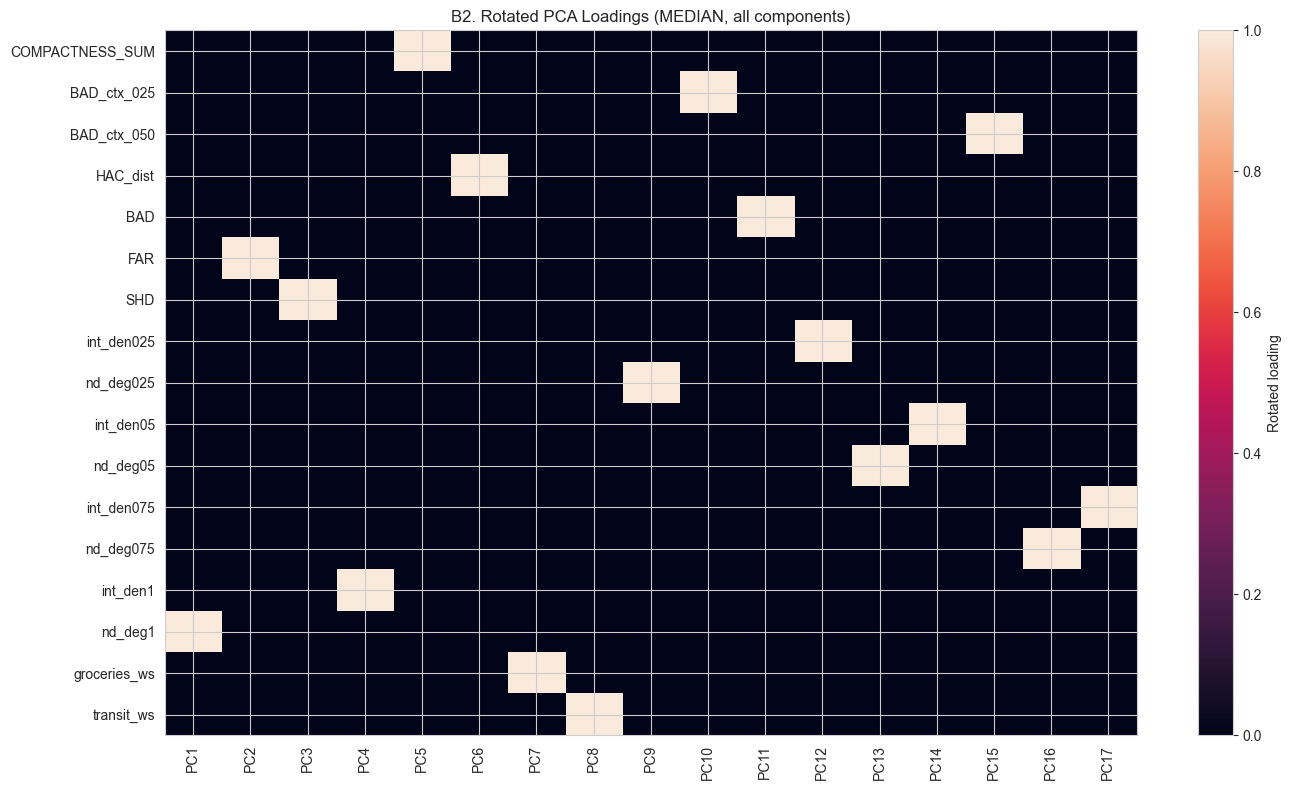

In [39]:
# B2. PCA (MEDIAN): all components, varimax

rot_med_full = varimax_rotate(loadings_med)

plt.figure(figsize=(14, 8))
plt.imshow(rot_med_full.values, aspect="auto")
plt.colorbar(label="Rotated loading")
plt.yticks(range(len(rot_med_full.index)), rot_med_full.index)
plt.xticks(range(len(rot_med_full.columns)), rot_med_full.columns, rotation=90)
plt.title("B2. Rotated PCA Loadings (MEDIAN, all components)")
plt.tight_layout()
plt.show()


### B3. SOM (MEDIAN)


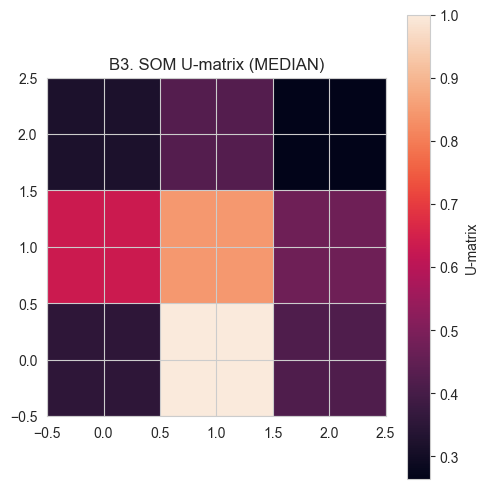

In [40]:
som_med = train_som(Xz_median)
bmu_med = som_bmu_df(som_med, Xz_median)

plot_umatrix(som_med, "B3. SOM U-matrix (MEDIAN)")

In [41]:
!jupyter nbconvert --to html --no-input PCA2.ipynb --output ../../../../output/Notebook_Outputs/time_series/PCA2.html

[NbConvertApp] Converting notebook PCA2.ipynb to html
[NbConvertApp] Writing 835778 bytes to ..\..\..\..\output\Notebook_Outputs\time_series\PCA2.html
